<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
            border-radius: 16px; padding: 48px 40px; text-align: center; margin-bottom: 8px;">
  <h1 style="color: #e2b96f; font-size: 2.2em; margin: 0 0 8px 0; letter-spacing: 1px; word-wrap: break-word;">
    TP Nro. 2 — Control de Rumbo<br>y Reconstrucción de Trayectoria
  </h1>
  <h2 style="color: #a8c6f0; font-size: 1.2em; font-weight: 400; margin: 0 0 24px 0;">
    IOR442 · Sistemas de Control · Dr. Mariano Scaramal
  </h2>
  <hr style="border-color: #e2b96f44; margin: 20px auto; width: 60%;">
  <p style="color: #c9d6e3; font-size: 1em; margin: 0;">
  </p>
</div>

In [1]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#ffffff',
    'axes.edgecolor':   '#cccccc',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.7,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'legend.fontsize':  10,
    'lines.linewidth':  2,
})

COL = {
    'ref':     '#e63946',   # rojo — referencia
    'psi':     '#457b9d',   # azul — ψ / salida
    'v':       '#2196F3',   # azul claro — velocidad lateral v
    'r':       '#FF9800',   # naranja — yaw rate r
    'tau':     '#9c27b0',   # violeta — señal de control τr
    'error':   '#333333',   # negro — error
    'tray':    '#e63946',   # rojo — trayectoria XY
    'start':   '#1565C0',   # azul oscuro — punto inicial
    'end':     '#212121',   # negro — punto final
    'fast':    '#4caf50',   # verde — polos rápidos
}


---
# Parte A - Control de Rumbo con Asignación de Polos

> Se diseña un controlador por realimentación de estados con integrador del error para
> seguir referencias de rumbo **sin error estacionario**.

## A.1 · Modelo en espacio de estados

A partir de las ecuaciones de movimiento del enunciado, con
$\mathbf{x} = [v,\, r,\, \psi]^T$, $u_c = \tau_r$ e $y = \psi$:

$$\dot{\mathbf{x}} = A\mathbf{x} + Bu_c, \qquad y = C\mathbf{x} + Du_c$$

$$A = \begin{pmatrix}-0.25 & -2 & 0\\ 0.08 & -0.35 & 0\\ 0 & 1 & 0\end{pmatrix},\quad
B = \begin{pmatrix}0\\ 0.62\\ 0\end{pmatrix},\quad
C = \begin{pmatrix}0 & 0 & 1\end{pmatrix},\quad D = 0$$

In [2]:
# Matrices del sistema original
A = np.array([[-0.25, -2,    0],
              [ 0.08, -0.35, 0],
              [ 0,     1,    0]])

B = np.array([[0   ],
              [0.62],
              [0   ]])

C = np.array([[0, 0, 1]])
D = np.array([[0]])

print("Matriz A:\n", A)
print("\nMatriz B:\n", B)
print("\nMatriz C:", C)
print("Matriz D:", D)

Matriz A:
 [[-0.25 -2.    0.  ]
 [ 0.08 -0.35  0.  ]
 [ 0.    1.    0.  ]]

Matriz B:
 [[0.  ]
 [0.62]
 [0.  ]]

Matriz C: [[0 0 1]]
Matriz D: [[0]]


## A.2 · Controlabilidad del sistema original

Se construye la matriz de controlabilidad $\mathcal{C} = [B,\; AB,\; A^2B]$ y se verifica
que su rango sea igual al número de estados ($n = 3$).

In [3]:
Co = ctrl.ctrb(A, B)
rango = np.linalg.matrix_rank(Co)
det = np.linalg.det(Co)

print(f"Matriz de controlabilidad Co:\n{np.round(Co, 4)}")
print(f"\nRango de Co : {rango}  (necesario: {A.shape[0]})")
print(f"det(Co): {det:.6f}")

if rango == A.shape[0]:
    print("\n Sistema CONTROLABLE → se puede diseñar realimentación de estados completa.")
else:
    print("\n Sistema NO controlable.")

Matriz de controlabilidad Co:
[[ 0.     -1.24    0.744 ]
 [ 0.62   -0.217  -0.0233]
 [ 0.      0.62   -0.217 ]]

Rango de Co : 3  (necesario: 3)
det(Co): 0.119164

 Sistema CONTROLABLE → se puede diseñar realimentación de estados completa.


## A.3 · Sistema aumentado con integrador del error

Para eliminar el error estacionario ante referencias constantes se agrega el estado integral
$\dot{\xi} = \psi_{\text{ref}} - \psi$.

El vector de estados aumentado es $\mathbf{x}_a = [v,\; r,\; \psi,\; \xi]^T$, y el sistema queda:

$$\dot{\mathbf{x}}_a = A_a\,\mathbf{x}_a + B_a\,\tau_r + E_a\,\psi_{\text{ref}}$$

$$A_a = \begin{pmatrix}A & 0\\ -C & 0\end{pmatrix},\quad
B_a = \begin{pmatrix}B\\ 0\end{pmatrix},\quad
E_a = \begin{pmatrix}0\\ \vdots\\ 1\end{pmatrix}$$

In [4]:
A_ext = np.block([[A, np.zeros((3, 1))],[-C, np.zeros((1, 1))]])

B_ext = np.vstack([B, [[0]]])
E_ext = np.array([[0], [0], [0], [1]])

C_ext = np.hstack([C, np.zeros((1, 1))])
D_ext = D

print("Aa (sistema aumentado):\n", np.round(A_ext, 4))
print("\nBa:\n", B_ext)
print("\nEa:", E_ext.T)
print("\nCa:", C_ext)

Aa (sistema aumentado):
 [[-0.25 -2.    0.    0.  ]
 [ 0.08 -0.35  0.    0.  ]
 [ 0.    1.    0.    0.  ]
 [ 0.    0.   -1.    0.  ]]

Ba:
 [[0.  ]
 [0.62]
 [0.  ]
 [0.  ]]

Ea: [[0 0 0 1]]

Ca: [[0. 0. 1. 0.]]


## A.4 · Controlabilidad del sistema aumentado

Se verifica que $\mathcal{C}_a$ tiene rango 4 para poder asignar los polos arbitrariamente.

In [5]:
Co_ext = ctrl.ctrb(A_ext, B_ext)
rango_ext = np.linalg.matrix_rank(Co_ext)
det_ext   = np.linalg.det(Co_ext)

print(f"Rango de Ca : {rango_ext}  (necesario: {A_ext.shape[0]})")
print(f"det(Ca) : {det_ext:.6f}")

if rango_ext == A_ext.shape[0]:
    print("\n Sistema aumentado CONTROLABLE → asignación de polos arbitraria posible.")
else:
    print("\n Sistema aumentado NO controlable.")

Rango de Ca : 4  (necesario: 4)
det(Ca) : -0.018470

 Sistema aumentado CONTROLABLE → asignación de polos arbitraria posible.


## A.5 · Diseño del controlador - Asignación de polos

Ley de control: $\tau_r = -K_a\,\mathbf{x}_a = -K_x\,\mathbf{x} - k_i\,\xi$

Polos deseados: $p_1 = -1.5$, $p_2 = -2.0$, $p_3 = -2.5$, $p_4 = -3.0$

In [6]:
#Asignación de polos
polos_deseados = [-1.5, -2.0, -2.5, -3.0]
K_ext = ctrl.place(A_ext, B_ext, polos_deseados)

Kx = K_ext[0, :3]
Ki = K_ext[0,  3]

print(f"Ka = {np.round(K_ext, 4)}")
print(f"\n  kv = {Kx[0]:.4f}")
print(f"  kr = {Kx[1]:.4f}")
print(f"  kψ = {Kx[2]:.4f}")
print(f"  ki = {Ki:.4f}")

Ka = [[-174.5181   13.5484 -304.8387 -145.1613]]

  kv = -174.5181
  kr = 13.5484
  kψ = -304.8387
  ki = -145.1613


## A.6 · Simulación a lazo cerrado ($T_f = 60\,\text{s}$)

Referencia de rumbo por tramos:

| Intervalo | $\psi_{\text{ref}}$ |
|-----------|----------------------|
| $t < 10$  | $0$ |
| $10 \le t < 25$ | $\pi/6 \approx 0.524$ rad |
| $25 \le t < 40$ | $-\pi/6$ rad |
| $40 \le t \le 60$ | $\pi/3 \approx 1.047$ rad |

In [7]:
tramos = [
    (0,  10,  1000, 0),
    (10, 25,  1500, np.pi/6),
    (25, 40,  1500, -np.pi/6),
    (40, 60,  2000, np.pi/3),
]

psi_ref = np.concatenate([np.full(n, ref) for (_, _, n, ref) in tramos])

# Función de simulación
def simular_sistema(A_a, B_a, C_a, D_a, K, tramos):
    """
    Simula el sistema aumentado a lazo cerrado tramo a tramo.
    Devuelve: t, y (salida), x_a (estados aumentados), tau_r
    """
    Kx_= K[0, :3]
    Ki_ = K[0, 3]
    Kx_mat = Kx_.reshape(1, -1)

    A_cl = np.block([[A - B @ Kx_mat,-B * Ki_], [-C, np.zeros((1, 1))]])
    B_cl = np.vstack([np.zeros((3, 1)), [[1.0]]])
    sys_cl= ctrl.ss(A_cl, B_cl, C_a, D_a)

    t_total, y_total, x_total = [], [], []
    X0 = np.zeros(4)

    for (t_ini, t_fin, n_pts, ref) in tramos:
        t_tramo = np.linspace(t_ini, t_fin, n_pts)
        t_out, y_out, x_out = ctrl.forced_response(sys_cl, T=t_tramo, U=ref, X0=X0, return_x=True)
        t_total.append(t_out)
        y_total.append(y_out)
        x_total.append(x_out)
        X0 = x_out[:, -1]

    t  = np.concatenate(t_total)
    y  = np.concatenate(y_total, axis=-1)
    xa = np.concatenate(x_total, axis=-1)

    # Señal de control
    tau = -(Kx_ @ xa[:3, :]) - Ki_ * xa[3, :]

    return t, y, xa, tau

#Simulación con polos originales
t1, y1, x1, tau1 = simular_sistema(A_ext, B_ext, C_ext, D_ext, K_ext, tramos)

print(" Simulación completada.")
print(f"Puntos de tiempo: {len(t1)}")
print(f"τr_max = {np.max(np.abs(tau1)):.2f}")

 Simulación completada.
Puntos de tiempo: 6000
τr_max = 18.61


### Seguimiento de referencia

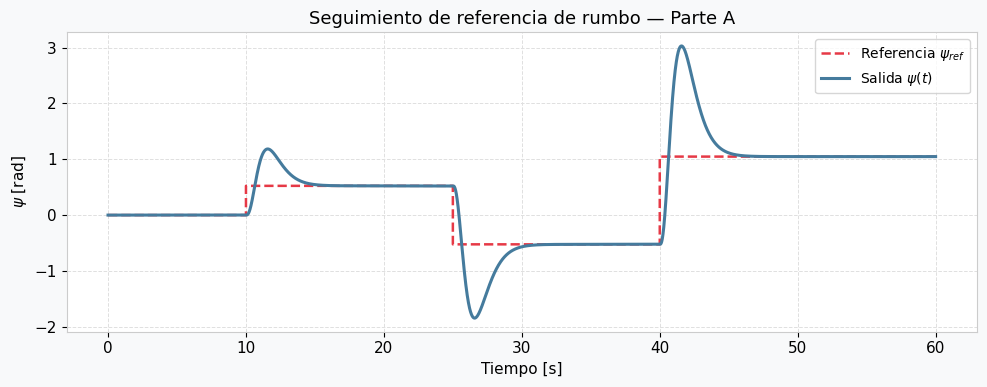

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t1, psi_ref, '--', color=COL['ref'], lw=1.8, label=r'Referencia $\psi_{ref}$')
ax.plot(t1, y1,'-',  color=COL['psi'], lw=2.2, label=r'Salida $\psi(t)$')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel(r'$\psi$ [rad]')
ax.set_title('Seguimiento de referencia de rumbo — Parte A')
ax.legend()
plt.tight_layout()
plt.show()

## A.7 · Error de seguimiento, estados y señal de control

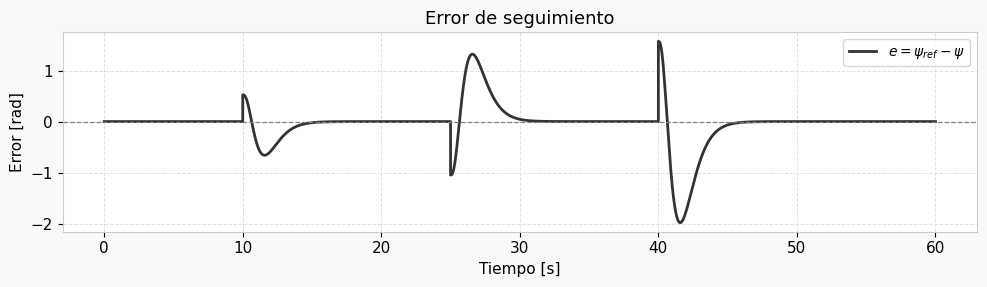

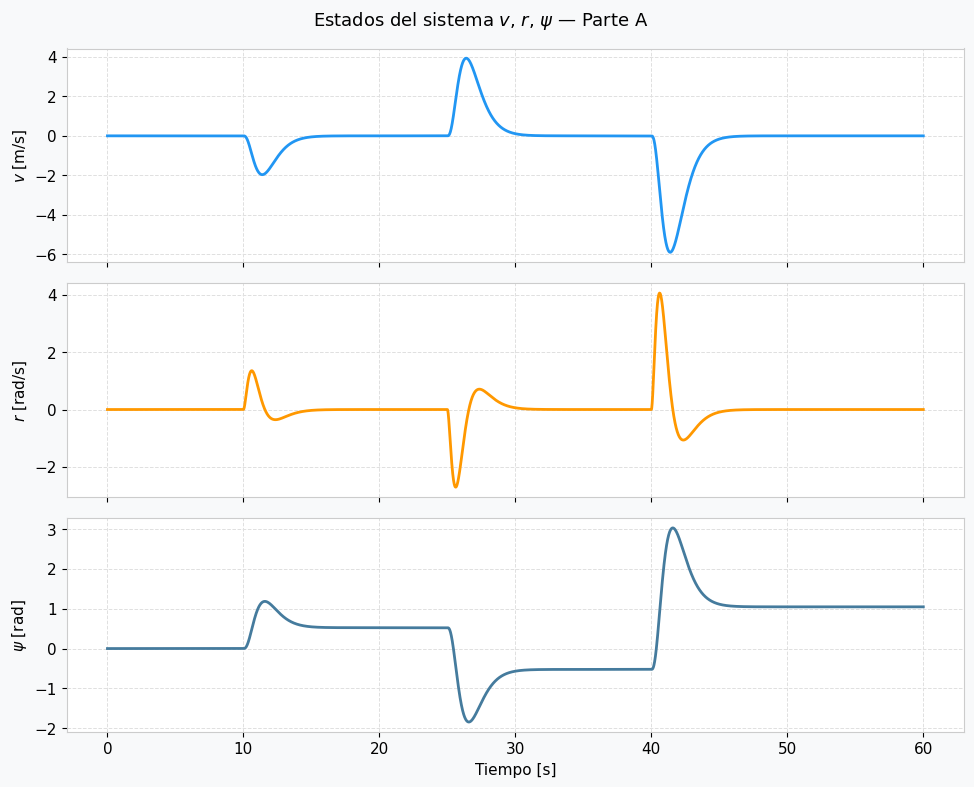

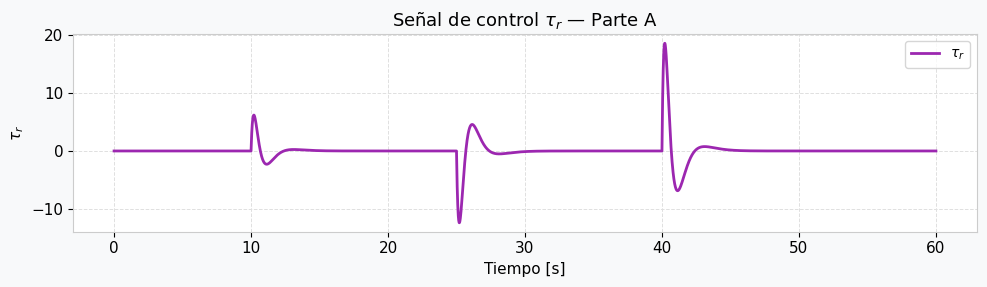

Pico máximo |τr| = 18.61


In [9]:
error1 = psi_ref - y1

# Error de seguimiento
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t1, error1, color=COL['error'], label=r'$e = \psi_{ref} - \psi$')
ax.axhline(0, color='gray', lw=0.9, ls='--')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Error [rad]')
ax.set_title('Error de seguimiento')
ax.legend()
plt.tight_layout()
plt.show()

# Estados v, r, ψ 
labels  = [r'$v$ [m/s]', r'$r$ [rad/s]', r'$\psi$ [rad]']
colores = [COL['v'], COL['r'], COL['psi']]

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, (lbl, col) in enumerate(zip(labels, colores)):
    axes[i].plot(t1, x1[i], color=col)
    axes[i].set_ylabel(lbl)
axes[-1].set_xlabel('Tiempo [s]')
fig.suptitle(r'Estados del sistema $v$, $r$, $\psi$ — Parte A', fontsize=13)
plt.tight_layout()
plt.show()

# Señal de control 
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t1, tau1, color=COL['tau'], label=r'$\tau_r$')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel(r'$\tau_r$')
ax.set_title(r'Señal de control $\tau_r$ — Parte A')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pico máximo |τr| = {np.max(np.abs(tau1)):.2f}")

### Comparación con polos más rápidos ($p = [-3,\,-4,\,-5,\,-6]$)

Ka polos originales : [[-174.52   13.55 -304.84 -145.16]]
Ka polos rápidos    : [[-3634.2     28.06 -7083.87 -2322.58]]


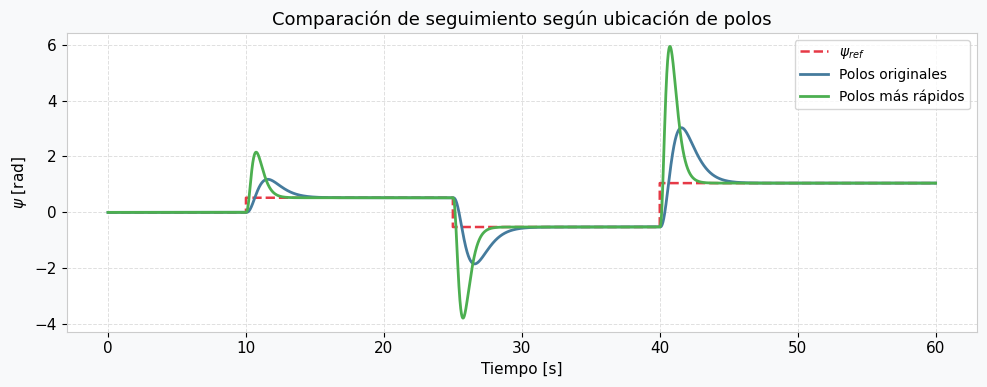

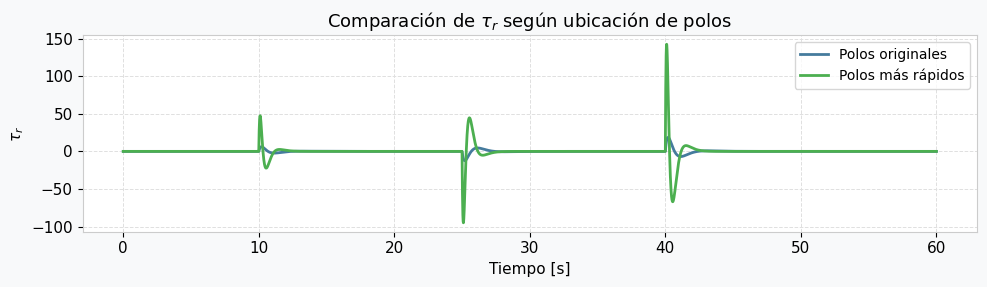


|τr|_max polos originales : 18.61
|τr|_max polos rápidos: 142.60


In [10]:
polos_rapidos = [-3.0, -4.0, -5.0, -6.0]
K_rap = ctrl.place(A_ext, B_ext, polos_rapidos)
t2, y2, x2, tau2 = simular_sistema(A_ext, B_ext, C_ext, D_ext, K_rap, tramos)

print(f"Ka polos originales : {np.round(K_ext,  2)}")
print(f"Ka polos rápidos    : {np.round(K_rap, 2)}")

# Seguimiento
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t1, psi_ref, '--', color=COL['ref'],  lw=1.8, label=r'$\psi_{ref}$')
ax.plot(t1, y1,      '-',  color=COL['psi'],  lw=2,   label='Polos originales')
ax.plot(t2, y2,      '-',  color=COL['fast'], lw=2,   label='Polos más rápidos')
ax.set_xlabel('Tiempo [s]');  ax.set_ylabel(r'$\psi$ [rad]')
ax.set_title('Comparación de seguimiento según ubicación de polos')
ax.legend();  plt.tight_layout();  plt.show()

# Control
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t1, tau1, color=COL['psi'],  label='Polos originales')
ax.plot(t2, tau2, color=COL['fast'], label='Polos más rápidos')
ax.set_xlabel('Tiempo [s]');  ax.set_ylabel(r'$\tau_r$')
ax.set_title(r'Comparación de $\tau_r$ según ubicación de polos')
ax.legend();  plt.tight_layout();  plt.show()

print(f"\n|τr|_max polos originales : {np.max(np.abs(tau1)):.2f}")
print(f"|τr|_max polos rápidos: {np.max(np.abs(tau2)):.2f}")

---
# Parte B - Reconstrucción de la Trayectoria en el Plano Inercial

> El controlador es el **mismo de la Parte A**. Aca solo se agregan las ecuaciones
> cinemáticas para visualizar la trayectoria $X$-$Y$ que recorre la embarcación.

## B.1 · Derivación de las ecuaciones cinemáticas

La embarcación tiene, en su propio sistema de referencia (*body frame*), dos velocidades traslacionales:
- $u_0$: longitudinal (hacia adelante, eje $x_b$)
- $v$: lateral (hacia estribor, eje $y_b$)

El *body frame* está rotado un ángulo $\psi$ respecto del sistema inercial. La rotación que lleva vectores del *body frame* al inercial es:

$$R(\psi) = \begin{pmatrix}\cos\psi & -\sin\psi \\ \sin\psi & \cos\psi\end{pmatrix}$$

Aplicando la transformación al vector de velocidades del cuerpo:

$$\begin{pmatrix}\dot{X} \\ \dot{Y}\end{pmatrix}
= R(\psi)\begin{pmatrix}u_0 \\ v\end{pmatrix}
= \begin{pmatrix}\cos\psi & -\sin\psi \\ \sin\psi & \cos\psi\end{pmatrix}\begin{pmatrix}u_0 \\ v\end{pmatrix}$$

Realizando el producto:

$$\boxed{\dot{X} = u_0\cos\psi - v\sin\psi}$$
$$\boxed{\dot{Y} = u_0\sin\psi + v\cos\psi}$$

que corresponden exactamente a las ecuaciones (13) y (14) del enunciado.

> **Nota:** cuando $v = 0$ (sin deslizamiento lateral), la dirección de movimiento coincide exactamente con $\psi$.
> Con $v \neq 0$ existe un ángulo de derrape (*sideslip*) que produce una leve diferencia entre la trayectoria real y el rumbo $\psi$.


## B.2 · Integración de las ecuaciones cinemáticas

Se parte desde el origen con condiciones iniciales nulas:
$X(0)=0$, $Y(0)=0$, $v(0)=0$, $r(0)=0$, $\psi(0)=0$.

In [11]:
u0 = 2.0 # velocidad longitudinal constante [m/s]

from scipy.interpolate import interp1d

# eliminamos duplicados en t1 antes de interpolar
_, idx_uniq = np.unique(t1, return_index=True)
t1_u = t1[idx_uniq]
x1_u = x1[:, idx_uniq]
y1_u= y1[idx_uniq]

v_interp = interp1d(t1_u, x1_u[0], kind='linear', fill_value='extrapolate')
psi_interp = interp1d(t1_u, y1_u, kind='linear', fill_value='extrapolate')

def cinematica(t, pos):
    v_t = v_interp(t)
    psi_t = psi_interp(t)
    dX = u0* np.cos(psi_t) - v_t * np.sin(psi_t)
    dY = u0 * np.sin(psi_t) + v_t * np.cos(psi_t)
    return [dX, dY]

sol = solve_ivp(
    cinematica,
    t_span=(t1_u[0], t1_u[-1]),
    y0=[0.0, 0.0],
    t_eval=t1_u,
    method='RK45',
    rtol=1e-6,
    atol=1e-8
)

X_tray = sol.y[0]
Y_tray = sol.y[1]

print(f" Integración completada.")
print(f" Posición final: X = {X_tray[-1]:.2f} m,  Y = {Y_tray[-1]:.2f} m")

 Integración completada.
 Posición final: X = 97.41 m,  Y = 38.12 m


## B.3 · Trayectoria en el plano inercial

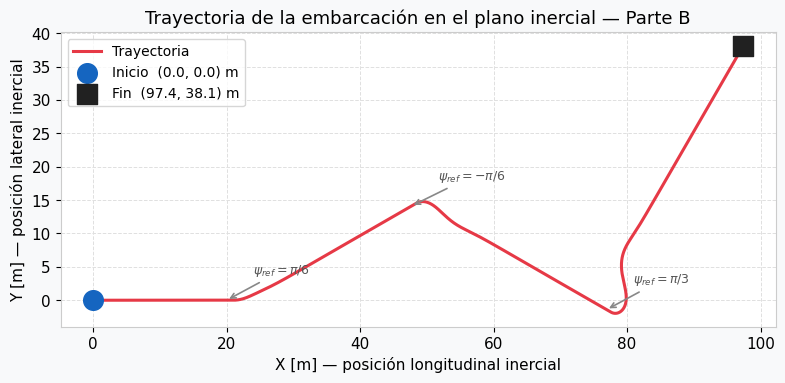

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

# Trayectoria
ax.plot(X_tray, Y_tray, '-', color=COL['tray'], lw=2.2, label='Trayectoria', zorder=2)

# Punto inicial
ax.scatter(X_tray[0], Y_tray[0], s=200, color=COL['start'], zorder=5, label=f'Inicio  ({X_tray[0]:.1f}, {Y_tray[0]:.1f}) m')

# Punto final
ax.scatter(X_tray[-1], Y_tray[-1], s=200, color=COL['end'], marker='s', zorder=5, label=f'Fin  ({X_tray[-1]:.1f}, {Y_tray[-1]:.1f}) m')

# Flechas de cambio de rumbo
cambios_t = [10, 25, 40]
cambios_ref = [r'$\psi_{ref}=\pi/6$', r'$\psi_{ref}=-\pi/6$', r'$\psi_{ref}=\pi/3$']
for tc, lbl in zip(cambios_t, cambios_ref):
    idx = np.argmin(np.abs(t1_u - tc))
    ax.annotate(lbl, xy=(X_tray[idx], Y_tray[idx]), xytext=(X_tray[idx] + 4, Y_tray[idx] + 4), fontsize=9, color='#555', arrowprops=dict(arrowstyle='->', color='#888', lw=1.2))

ax.set_xlabel('X [m] — posición longitudinal inercial')
ax.set_ylabel('Y [m] — posición lateral inercial')
ax.set_title('Trayectoria de la embarcación en el plano inercial — Parte B')
ax.legend(loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## B.4 · Efecto de los cambios de referencia sobre la trayectoria

| Intervalo | $\psi_{\text{ref}}$ | Efecto en trayectoria |
|-----------|---------------------|-----------------------|
| $0$–$10$ s | $0$ | La embarcación avanza en línea recta hacia $+X$ |
| $10$–$25$ s | $\pi/6 \approx 30°$ | Giro suave a la izquierda (hacia $+Y$) |
| $25$–$40$ s | $-\pi/6 \approx -30°$ | Giro a la derecha (hacia $-Y$), trayectoria más recta |
| $40$–$60$ s | $\pi/3 \approx 60°$ | Giro pronunciado a la izquierda, mayor curvatura |

Dado que el controlador tiene **dinámica transitoria** (~10 s de asentamiento), los cambios de rumbo
no se traducen en giros instantáneos: la trayectoria muestra curvaturas **suaves** en lugar de
esquinas, lo que es físicamente consistente con la inercia de la embarcación.

La velocidad lateral $v(t) \neq 0$ durante los transitorios produce un pequeño *sideslip*: la
dirección instantánea de movimiento difiere ligeramente de $\psi$, generando una leve
diferencia entre la trayectoria real y la que correspondería a seguimiento perfecto de rumbo.

## B.5 · Observaciones finales

**¿Se podría controlar $X$ e $Y$ directamente?**
Sí, pero cambiaría radicalmente el problema: pasaría de ser SISO (entrada $\tau_r$, salida $\psi$)
a un sistema MIMO con salidas $[X, Y]$. Además, las ecuaciones cinemáticas son **no lineales**
(aparecen $\cos\psi$ y $\sin\psi$), lo que requiere técnicas de control no lineal o linealización
en torno a trayectorias de referencia.

**¿La trayectoria es consistente con los cambios de rumbo?**
Sí: cada cambio en $\psi_{\text{ref}}$ se refleja en una curvatura de la trayectoria en la
dirección correcta, con la demora propia del transitorio del controlador.

**Limitaciones del esquema:**
- Sin control de posición, errores acumulados en $v(t)$ desplazan la trayectoria real respecto
  de la ideal.
- No hay retroalimentación de $X$ ni $Y$, por lo que perturbaciones externas (corrientes, viento)
  no se compensan en posición.


---
# Parte C - Control de Rumbo Mediante LQI

## C.1 · Ecuación de estado y función de costo

Para esta parte, en vez de elegir polos, vamos a elegir qué nos importa más (seguir bien la referencia, o no gastar mucho actuador) y la computadora calcula sola la ganancia K óptima para ese objetivo. Es un cambio de "nosotras decidimos la dinámica" a "decidimos las prioridades, y el algoritmo encuentra la dinámica óptima para esas prioridades".

El sistema utilizado es el **mismo sistema aumentado** de la Parte A (no cambia la física, cambia el método de diseño de la ganancia):

$$\dot{\mathbf{x}}_a = A_a\,\mathbf{x}_a + B_a\,\tau_r, \qquad \mathbf{x}_a = [v,\,r,\,\psi,\,\xi]^T$$

reutilizando las matrices `A_ext`, `B_ext`, `C_ext`, `D_ext` ya definidas en la Parte A.

El controlador LQI busca la ganancia $\tau_r = -K_a\,\mathbf{x}_a$ que minimiza el funcional de costo cuadrático:

$$J = \int_0^{\infty} \left( \mathbf{x}_a^T Q_a\, \mathbf{x}_a \;+\; \tau_r^T R\, \tau_r \right)\, dt$$

- $Q_a \in \mathbb{R}^{4\times4}$ (semidefinida positiva): penaliza el costo de que cada estado $(v, r, \psi, \xi)$ se aleje de cero.
- $R \in \mathbb{R}^{1\times1}$ (positiva, el sistema es SISO): penaliza el costo de usar el actuador $\tau_r$.

A diferencia de la asignación de polos (donde se elige directamente la dinámica deseada), en LQI se elige **cuánto penalizar cada cosa**, y los polos en lazo cerrado resultan de ese balance. Aumentar $R$ respecto de $Q_a$ hace que el controlador sea más conservador con el actuador → menor esfuerzo, a costa de una respuesta más lenta.

## C.2 · Verificación de aplicabilidad de LQI

LQI requiere:
1. **Controlabilidad** del par $(A_a, B_a)$, que ya verificamos en **A.4** (rango completo = 4).
2. $Q_a \succeq 0$ y $R > 0$ que se cumple por construcción al elegir $Q_a$ diagonal con entradas $\geq 0$ y $R>0$.

No nos es necesario volver a calcular la controlabilidad (reutilizamos el resultado de la Parte A!)

In [13]:
print(f"Rango de Ca (controlabilidad del sistema aumentado): {rango_ext} / {A_ext.shape[0]}")
print("→ Sistema aumentado controlable ⇒ es posible aplicar LQI sin restricciones adicionales.")

Rango de Ca (controlabilidad del sistema aumentado): 4 / 4
→ Sistema aumentado controlable ⇒ es posible aplicar LQI sin restricciones adicionales.


## C.3 · Propuesta de matrices de ponderación $Q_a$ y $R$

Fijamos la **estructura** de $Q_a$ (diagonal) y se variamos $R$ para mostrar el compromiso esfuerzo/velocidad pedido por el enunciado:

$$Q_a = \mathrm{diag}(q_v,\, q_r,\, q_\psi,\, q_\xi) = \mathrm{diag}(1,\, 1,\, 50,\, 5)$$

**Justificación de los pesos:**
- $\psi$ (peso alto, 50): es la salida que efectivamente se quiere seguir.
- $\xi$ (peso moderado, 5): si se penaliza muy poco, el integrador es como que deja de "preocuparse" por el error acumulado y la respuesta en estado estacionario se volveríoa lenta.
- $v$, $r$ (peso bajo, 1): son estados internos de la dinámica lateral, no son el objetivo de control en sí, solo nos interesa que no diverjan.

Se evalúan **tres diseños representativos**, aumentando $R$ en cada caso:

| Diseño | $R$ | Idea de diseño |
|---|---|---|
| LQI-1 | 1  | Esfuerzo bajo, seguimiento todavía ágil |
| LQI-2 | 20 | Esfuerzo más bajo, seguimiento algo más lento |
| LQI-3 | 80 | Esfuerzo mínimo, prioriza no exigir al actuador |

Vamos entonces a probar tres valores de R manteniendo Q_a fijo, para ver qué pasa cuando le subimos el "precio" de usar el actuador. A medida que R sube, el algoritmo debería volverse más tacaño con τ_r, probablemente veamos que el controlador responde más lento pero con menos esfuerzo.

In [14]:
Qa = np.diag([1, 1, 50, 5])

disenos_lqi = {
    'LQI-1 (R=1)':  1,
    'LQI-2 (R=20)': 20,
    'LQI-3 (R=80)': 80,
}

resultados_lqi = {}
for nombre, R_val in disenos_lqi.items():
    R = np.array([[R_val]])
    K_lqi, S_lqi, E_lqi = ctrl.lqr(A_ext, B_ext, Qa, R)
    t_l, y_l, x_l, tau_l = simular_sistema(A_ext, B_ext, C_ext, D_ext, K_lqi, tramos)
    resultados_lqi[nombre] = dict(K=K_lqi, t=t_l, y=y_l, x=x_l, tau=tau_l)
    print(f"{nombre}: Ka = {np.round(K_lqi, 3)}  |  tau_r_max = {np.max(np.abs(tau_l)):.3f}")

print(f"\nReferencia - Parte A (pole placement): tau_r_max = {np.max(np.abs(tau1)):.3f}")

LQI-1 (R=1): Ka = [[ 0.074  4.817  8.719 -2.236]]  |  tau_r_max = 0.749
LQI-2 (R=20): Ka = [[ 0.11   2.1    2.306 -0.5  ]]  |  tau_r_max = 0.376
LQI-3 (R=80): Ka = [[ 0.108  1.39   1.298 -0.25 ]]  |  tau_r_max = 0.283

Referencia - Parte A (pole placement): tau_r_max = 18.607


## C.5 · Comparación con la Parte A: error, estados y señal de control

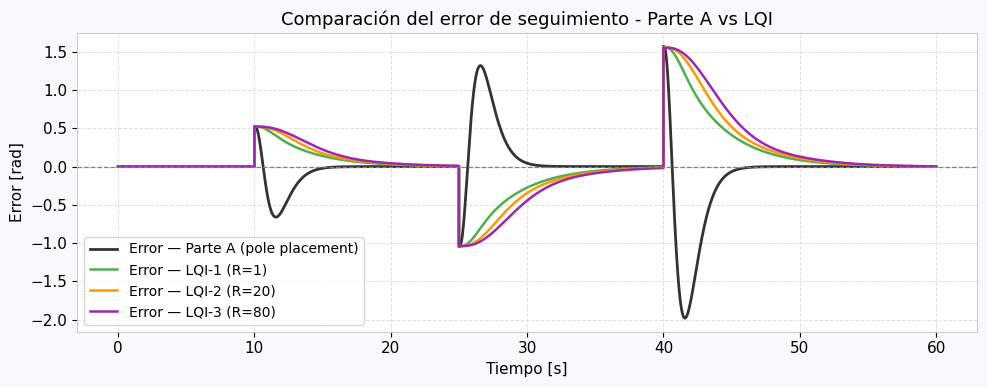

In [15]:
colores_lqi = ['#4caf50', '#ff9800', '#9c27b0']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t1, psi_ref - y1, color=COL['error'], lw=2, label='Error — Parte A (pole placement)')
for (nombre, res), col in zip(resultados_lqi.items(), colores_lqi):
    ax.plot(res['t'], psi_ref - res['y'], color=col, lw=1.8, label=f'Error — {nombre}')
ax.axhline(0, color='gray', lw=0.9, ls='--')
ax.set_xlabel('Tiempo [s]'); ax.set_ylabel('Error [rad]')
ax.set_title('Comparación del error de seguimiento - Parte A vs LQI')
ax.legend(); plt.tight_layout(); plt.show()

La Parte A llega al error cero más rápido en tiempo absoluto, pero a costa de un sobrepico pronunciado y de un esfuerzo de control bastante bruto. Los diseños LQI sacrifican un poco de velocidad de convergencia (sobre todo LQI-3, el más conservador) a cambio de una respuesta sin sobrepico y con un esfuerzo de control drásticamente menor (~0.3-0.75 vs ~18.6).

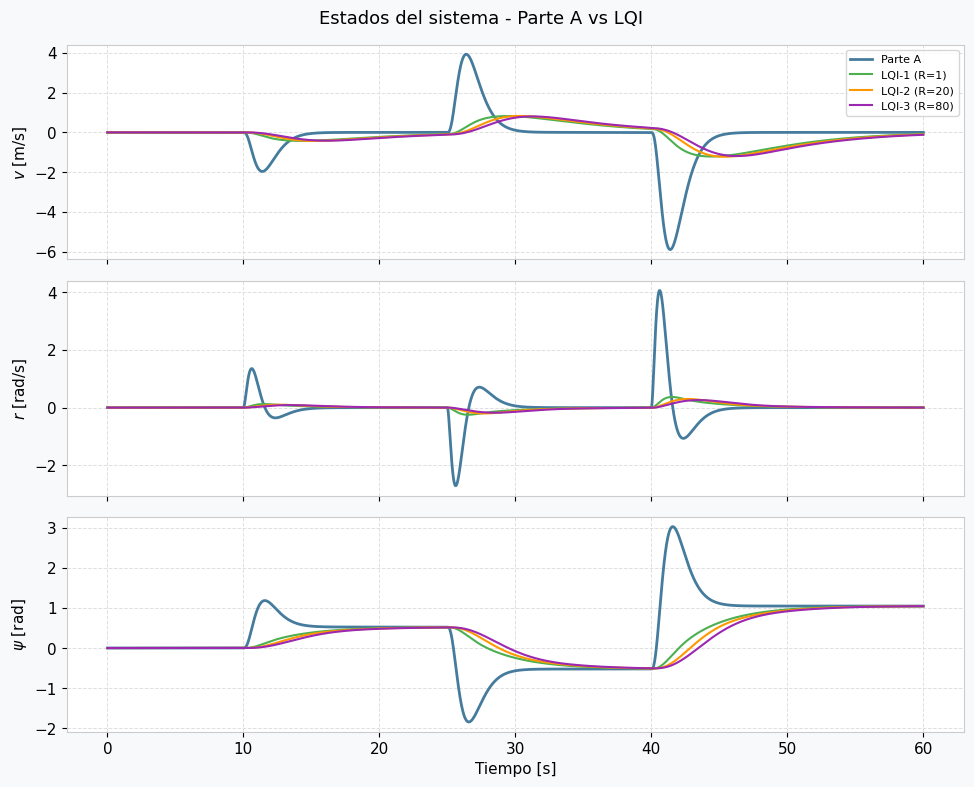

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = [r'$v$ [m/s]', r'$r$ [rad/s]', r'$\psi$ [rad]']

for i, lbl in enumerate(labels):
    axes[i].plot(t1, x1[i], color=COL['psi'], lw=2, label='Parte A')
    for (nombre, res), col in zip(resultados_lqi.items(), colores_lqi):
        axes[i].plot(res['t'], res['x'][i], color=col, lw=1.5, label=nombre)
    axes[i].set_ylabel(lbl)
axes[0].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Tiempo [s]')
fig.suptitle('Estados del sistema - Parte A vs LQI', fontsize=13)
plt.tight_layout(); plt.show()

Los estados v y r muestran picos de transitorio mucho mayores en la Parte A que en cualquier diseño LQI (hasta ~4-5 veces más grandes), y ψ presenta un sobrepico pronunciado (~3 rad frente a una referencia de ~1.05 rad) que no aparece en los diseños LQI. Esto confirma que la rapidez de la Parte A se logra a costa de excursiones grandes en los estados internos del sistema, consistente con el mayor esfuerzo de control observado.

v y r son justamente los "estados internos" a los que le pusimos peso bajo (1) en $Q_a$ no nos importa que se muevan mucho per se. Pero si observamos que en la Parte A se mueven muchísimo más que en los LQI, aunque ahí no elegimos ningún peso para ellos (porque pole placement no tiene esa noción). Eso es la consecuencia directa de pedir polos rápidos sin pensar en el costo: para lograr que $\psi$ reaccione tan rápido, el sistema tiene que "sacudir" mucho v y r por el camino, y esa sacudida es precisamente lo que le exige tanto esfuerzo a $\tau_r$ (los ~18.6 que vimos en C.5c).
LQI, al penalizar el esfuerzo de control, automáticamente evita esas sacudidas grandes en v y r, no porque les pusimos peso directamente, sino como efecto colateral de no permitir que $\tau_r$ se dispare.

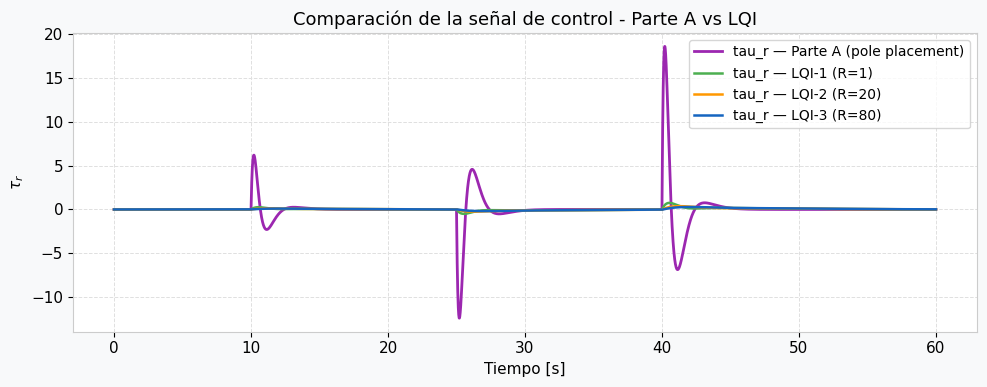

tau_r_max Parte A: 18.607
tau_r_max LQI-1 (R=1)   : 0.749
tau_r_max LQI-2 (R=20)  : 0.376
tau_r_max LQI-3 (R=80)  : 0.283


In [17]:
colores_lqi = ['#4caf50', '#ff9800', '#1565C0']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t1, tau1, color=COL['tau'], lw=2, label='tau_r — Parte A (pole placement)')
for (nombre, res), col in zip(resultados_lqi.items(), colores_lqi):
    ax.plot(res['t'], res['tau'], color=col, lw=1.8, label=f'tau_r — {nombre}')
ax.set_xlabel('Tiempo [s]'); ax.set_ylabel(r'$\tau_r$')
ax.set_title('Comparación de la señal de control - Parte A vs LQI')
ax.legend(); plt.tight_layout(); plt.show()

print(f"tau_r_max Parte A: {np.max(np.abs(tau1)):.3f}")
for nombre, res in resultados_lqi.items():
    print(f"tau_r_max {nombre:<14}: {np.max(np.abs(res['tau'])):.3f}")

La señal de control $\tau_r$ de la Parte A alcanza picos de hasta ~18.6, mientras que los tres diseños LQI se mantienen en el rango de 0.28 a 0.75, una reducción de entre 25 y 66 veces. Esto nos confirma que el objetivo de diseño de la Parte C (reducir el esfuerzo de control respecto de la Parte A) se cumple bien! Incluso con el diseño LQI menos conservador (R=1), y que la velocidad de respuesta de la Parte A se obtuvo a costa de exigir al actuador un esfuerzo muy por encima de lo necesario para el objetivo de seguimiento planteado.

## C.6 · Reconstrucción de la trayectoria XY para cada diseño LQI

Mismo procedimiento de integración cinemática que en **B.2**, aplicado ahora a $v(t)$ y $\psi(t)$ de cada diseño LQI.

In [18]:
def reconstruir_trayectoria(t, x, y):
    _, idx = np.unique(t, return_index=True)
    t_u, x_u, y_u = t[idx], x[:, idx], y[idx]
    v_interp   = interp1d(t_u, x_u[0], kind='linear', fill_value='extrapolate')
    psi_interp = interp1d(t_u, y_u,    kind='linear', fill_value='extrapolate')

    def cinematica(t, pos):
        v_t, psi_t = v_interp(t), psi_interp(t)
        dX = u0 * np.cos(psi_t) - v_t * np.sin(psi_t)
        dY = u0 * np.sin(psi_t) + v_t * np.cos(psi_t)
        return [dX, dY]

    sol = solve_ivp(cinematica, t_span=(t_u[0], t_u[-1]), y0=[0.0, 0.0], t_eval=t_u, method='RK45', rtol=1e-6, atol=1e-8)
    return sol.y[0], sol.y[1]

for nombre, res in resultados_lqi.items():
    X_l, Y_l = reconstruir_trayectoria(res['t'], res['x'], res['y'])
    res['X'], res['Y'] = X_l, Y_l

print("Trayectorias reconstruidas para los 3 diseños LQI.")
for nombre, res in resultados_lqi.items():
    print(f"{nombre}: posición final = ({res['X'][-1]:.2f}, {res['Y'][-1]:.2f}) m")


Trayectorias reconstruidas para los 3 diseños LQI.
LQI-1 (R=1): posición final = (112.02, 24.27) m
LQI-2 (R=20): posición final = (112.65, 23.06) m
LQI-3 (R=80): posición final = (113.17, 22.06) m


Las posiciones finales reflejan la diferencia de velocidad de respuesta entre controladores: la Parte A, al converger más rápido a cada cambio de rumbo, acumula más desplazamiento lateral (Y=38.12 m) que los diseños LQI (Y entre 22 y 24 m), que tardan más en orientarse hacia cada nueva referencia y por lo tanto recorren más distancia longitudinal (X) antes de completar el giro. Esta tendencia es monótona con R: a mayor penalización del esfuerzo de control, más lenta la respuesta angular y menor el desplazamiento lateral logrado en los mismos 60 segundos de simulación.

## C.7 · Comparación de trayectorias — Parte A vs Parte C

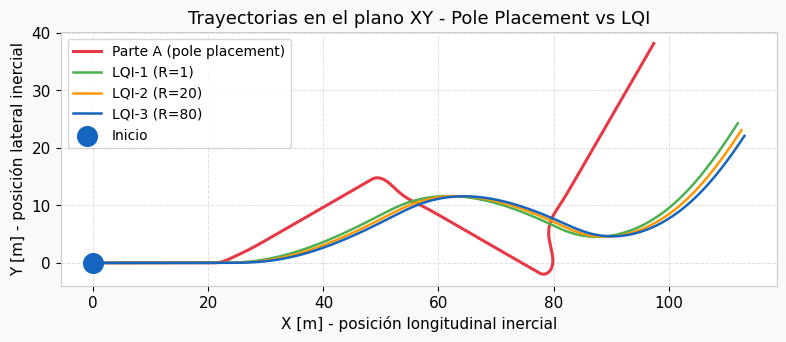

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(X_tray, Y_tray, '-', color=COL['tray'], lw=2.2, label='Parte A (pole placement)')
for (nombre, res), col in zip(resultados_lqi.items(), colores_lqi):
    ax.plot(res['X'], res['Y'], '-', color=col, lw=1.8, label=nombre)

ax.scatter(0, 0, s=200, color=COL['start'], zorder=5, label='Inicio')
ax.set_xlabel('X [m] - posición longitudinal inercial')
ax.set_ylabel('Y [m] - posición lateral inercial')
ax.set_title('Trayectorias en el plano XY - Pole Placement vs LQI')
ax.legend(loc='upper left'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()


La trayectoria de la Parte A presenta curvaturas pronunciadas y un tramo donde la posición lateral se vuelve negativa (cerca de X≈80 m), que es la manifestación espacial directa del sobrepico observado en $\psi(t)$ en esa misma ventana temporal (t≈25-30 s). Las trayectorias LQI, al no presentar sobrepico en el rumbo, resultan en curvas considerablemente más suaves y monótonas, confirmando de forma visual el comportamiento ya identificado en los gráficos de estados (C.5b).

## C.8 · Ventajas y desventajas: Asignación de Polos vs LQI

**Asignación de polos (Parte A):**
Ventajas:
- Control directo e intuitivo: se elige exactamente dónde quedan los polos del sistema en lazo cerrado.
- Cálculo simple (`ctrl.place`), sin necesidad de definir matrices de costo.
Desventajas: 
- No existe una noción explícita de "costo": los polos elegidos para lograr buena velocidad de respuesta pueden exigir un esfuerzo de control desproporcionado (en este caso, $|\tau_r|_{max} \approx 18.6$, muy por encima de cualquiera de los diseños LQI).
- Elegir polos "a ojo" no garantiza un buen compromiso velocidad/esfuerzo: hay que iterar manualmente probando distintas ubicaciones.

**LQI (Parte C):**
Ventajas:
- Permite expresar el objetivo de diseño directamente como un costo a minimizar (¿qué importa más: seguir bien la referencia, o gastar poco actuador?).
- La ganancia óptima se obtiene automáticamente dado ese costo, sin necesidad de adivinar polos.
- Permite reducir el esfuerzo de control de forma sistemática aumentando $R$, a costa de una respuesta más lenta, un compromiso explícito y ajustable.
Desventajas:
- Los pesos de $Q_a$ y $R$ no tienen un significado físico directo, requieren ajuste por prueba y error (a mano) para lograr el comportamiento deseado.
- Para sistemas más complejos, elegir una $Q_a$ con sentido físico (no solo diagonal arbitraria) puede no ser tan sencillo.